# Correlation

This notebook is the practical companion to the Correlation chapter. It focuses on calculations, visualisation, Python implementation, interpretation, and practice.


## 1. Learning Goals

- Calculate covariance and Pearson correlation.
- Visualise relationships with scatter plots.
- Calculate Spearman rank correlation.
- Compare Pearson and Spearman results.
- Build a correlation matrix.
- Perform a Pearson significance test.
- Investigate the effect of an outlier.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


## 2. Create Paired Data


In [2]:
df = pd.DataFrame({
    "study_hours": [2, 3, 4, 5, 6, 7],
    "marks": [45, 50, 54, 61, 65, 70]
})

df


,study_hours,marks
0,2,45
1,3,50
2,4,54
3,5,61
4,6,65
5,7,70


## 3. Scatter Plot


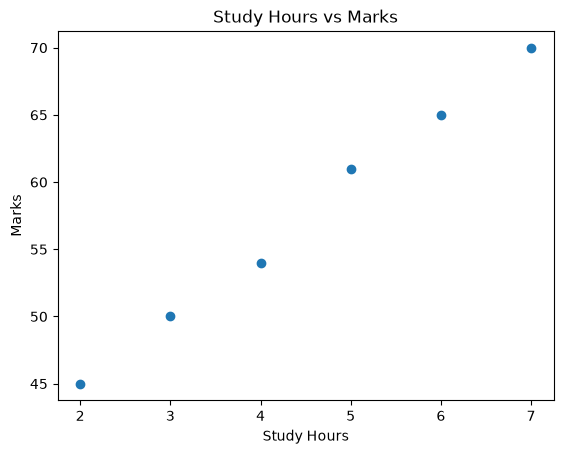

In [3]:
plt.scatter(df["study_hours"], df["marks"])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.show()


## 4. Covariance


In [4]:
covariance = df["study_hours"].cov(df["marks"])
print("Sample covariance:", covariance)


Sample covariance: 17.7


## 5. Pearson Correlation


In [5]:
r = df["study_hours"].corr(df["marks"])
print("Pearson correlation:", r)

r_scipy, p_value = pearsonr(df["study_hours"], df["marks"])
print("Pearson r:", r_scipy)
print("p-value:", p_value)


Pearson correlation: 0.9978365282791977
Pearson r: 0.9978365282791978
p-value: 7.015851646504119e-06


## 6. Spearman Rank Correlation


In [6]:
rho = df["study_hours"].corr(df["marks"], method="spearman")
print("Spearman correlation:", rho)

rho_scipy, p_spearman = spearmanr(df["study_hours"], df["marks"])
print("Spearman rho:", rho_scipy)
print("p-value:", p_spearman)


Spearman correlation: 1.0
Spearman rho: 1.0
p-value: 0.0


## 7. Manual Pearson Calculation


In [7]:
x = df["study_hours"].to_numpy(dtype=float)
y = df["marks"].to_numpy(dtype=float)

x_bar = x.mean()
y_bar = y.mean()

numerator = np.sum((x - x_bar) * (y - y_bar))
denominator = np.sqrt(np.sum((x - x_bar)**2) * np.sum((y - y_bar)**2))
r_manual = numerator / denominator

print("x mean:", x_bar)
print("y mean:", y_bar)
print("Numerator:", numerator)
print("Denominator:", denominator)
print("Manual Pearson r:", r_manual)


x mean: 4.5
y mean: 57.5
Numerator: 88.5
Denominator: 88.69188237939254
Manual Pearson r: 0.9978365282791977


## 8. Correlation Matrix


In [8]:
data = pd.DataFrame({
    "study_hours": [2, 3, 4, 5, 6, 7, 8, 9],
    "attendance": [60, 65, 70, 72, 78, 82, 88, 92],
    "marks": [45, 50, 54, 61, 65, 70, 76, 84]
})

corr_matrix = data.corr(numeric_only=True)
corr_matrix


,study_hours,attendance,marks
study_hours,1.000000,0.997222,0.996535
attendance,0.997222,1.000000,0.993044
marks,0.996535,0.993044,1.000000


## 9. Correlation Heatmap


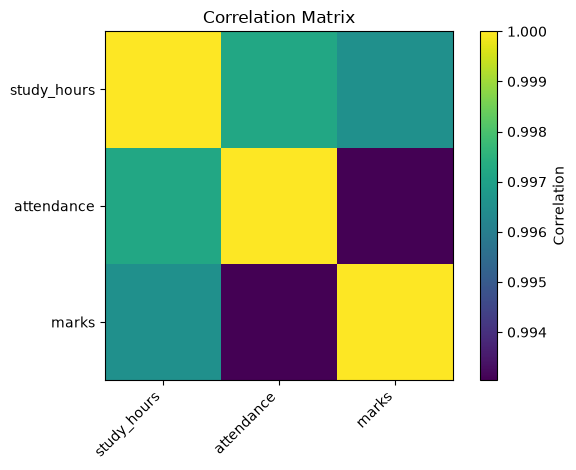

In [9]:
plt.imshow(corr_matrix, interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 10. Outlier Effect


In [10]:
base_x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
base_y = np.array([2, 4, 5, 8, 9, 12, 13, 15], dtype=float)

r_without_outlier = np.corrcoef(base_x, base_y)[0, 1]

x_with_outlier = np.append(base_x, 20)
y_with_outlier = np.append(base_y, 2)
r_with_outlier = np.corrcoef(x_with_outlier, y_with_outlier)[0, 1]

print("Correlation without unusual point:", r_without_outlier)
print("Correlation with unusual point:", r_with_outlier)


Correlation without unusual point: 0.9953064455909649
Correlation with unusual point: -0.048214033592263776


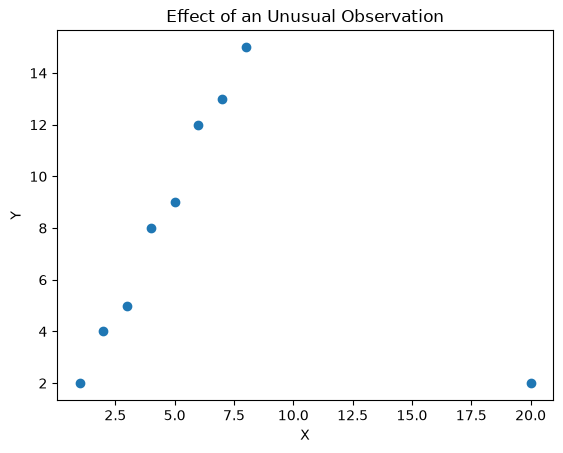

In [11]:
plt.scatter(x_with_outlier, y_with_outlier)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Effect of an Unusual Observation")
plt.show()


## 11. Nonlinear Relationship

Pearson correlation measures linear association. This example creates a curved relationship.


Pearson correlation: 8.97451530207283e-17


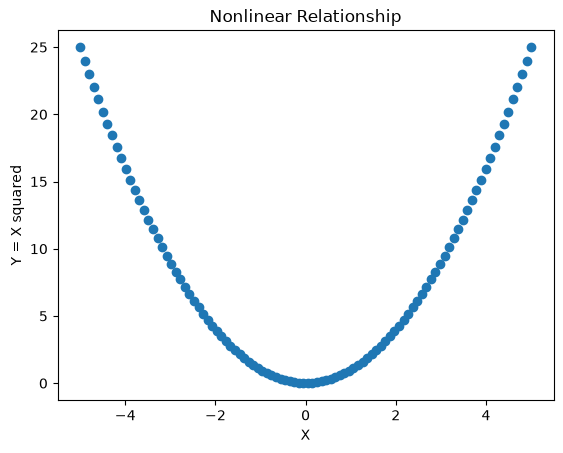

In [12]:
x_curve = np.linspace(-5, 5, 100)
y_curve = x_curve ** 2

print("Pearson correlation:", np.corrcoef(x_curve, y_curve)[0, 1])

plt.scatter(x_curve, y_curve)
plt.xlabel("X")
plt.ylabel("Y = X squared")
plt.title("Nonlinear Relationship")
plt.show()


## 12. Spearman Ranking Example


In [13]:
rank_df = pd.DataFrame({
    "exam_1_rank": [1, 2, 3, 4, 5],
    "exam_2_rank": [2, 1, 3, 5, 4]
})

rank_df["d"] = rank_df["exam_1_rank"] - rank_df["exam_2_rank"]
rank_df["d_squared"] = rank_df["d"] ** 2
rank_df


,exam_1_rank,exam_2_rank,d,d_squared
0,1,2,-1,1
1,2,1,1,1
2,3,3,0,0
3,4,5,-1,1
4,5,4,1,1


In [14]:
n = len(rank_df)
rho_manual = 1 - (6 * rank_df["d_squared"].sum()) / (n * (n**2 - 1))
print("Manual Spearman rho:", rho_manual)


Manual Spearman rho: 0.8


## 13. Partial Correlation Practice

For three variables:

$$
r_{XY\cdot Z}=\frac{r_{XY}-r_{XZ}r_{YZ}}{\sqrt{(1-r_{XZ}^2)(1-r_{YZ}^2)}}
$$


In [15]:
r_xy = 0.70
r_xz = 0.50
r_yz = 0.40

partial_r = (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
print("Partial correlation:", partial_r)


Partial correlation: 0.6299407883487119


## 14. Practice Questions

1. Create two arrays with 10 paired observations and calculate covariance.
2. Calculate Pearson correlation manually and with pandas. Verify the results.
3. Create a scatter plot and describe its direction and strength.
4. Create a dataset containing an outlier and compare correlation before and after adding it.
5. Create a nonlinear relationship and compare its scatter plot with Pearson correlation.
6. Calculate Spearman correlation for two ranking variables.
7. Create a three-variable correlation matrix and identify the strongest positive and negative relationships.
8. Use `scipy.stats.pearsonr()` and interpret both $r$ and the p-value.
9. Explain why a correlation of zero does not necessarily mean independence.
10. Write a short report of one correlation analysis without using causal language.


## 15. Final Practical Checklist

- Check that observations are correctly paired.
- Plot the data before interpreting the coefficient.
- Check for outliers and nonlinear patterns.
- Choose Pearson or Spearman based on the question and data.
- Report direction and magnitude.
- Include sample size and uncertainty when appropriate.
- Do not interpret correlation as proof of causation.
